### Множественная линейная регрессия на чистых данных

#### Цель работы

Познакомиться с основными приемами работы с множественными регрессионными моделями с использованием библиотеки sklearn.

#### Содержание работы

1. Ваша задача - построить предиктивную модель предсказания целевой переменной в зависимости от значения нескольких факторов (признаков).
2. Загрузите датасет из приложения. Вам понадобится два файла - отдельно с признаками (помечен x) и значениями целевой переменной (помечен y). Файлы не содержат заголовков столбцов и строк. Выведите первые строки датасета.
3. Сделайте количественное описание датасета: количество точек данных, признаков, статистику по каждому признаку.
Для целевой и каждого из признаков постройте парную регрессионную модель. Визуализируйте линию регрессии и исходные данные на графике. При помощи коэффициентов оцените силу связи.
Постройте модель множественной линейной регрессии целевой переменной от всех показателей. Оцените качество регрессии, сделайте вывод.


Для начала работы как всегда выполним стандартный импорт необходимых библиотек:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Теперь мы можем приступить к чтению данных. Для этой работы представлено сразу 50 однотипных датасетов. Мы для примера возьмем самый первый (с названием "0"). Читать данные можно многими способами, но мы воспользуемся самым простым чтением по URL:

In [2]:
x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/1_x.csv")

In [3]:
x.head()

,1.5998646673071175,0.34059791776594267,-0.6033998233687305,0.15058611793183632,-0.2096765504328273,0.9550448072396549,0.347682255109066
0,1.472656,0.466832,-1.947130,0.625906,0.589354,0.753521,-2.138552
1,0.279378,-1.717121,0.251069,0.730013,0.301801,-0.206711,0.894811
2,0.450771,1.133196,-0.294028,-2.595338,0.313911,1.953527,0.359938
3,1.507042,0.932115,-0.789549,1.043712,-1.404000,-0.124354,-0.921117
4,-0.793739,-1.249947,-0.048617,2.050793,-0.206069,-1.880998,0.596198


Если выполнить этот код то при внимательном рассмотрении можно заметить одну ошибку. Первая строка данных была помещена в заголовки строк. Чаще всего в файле с данными первая строка как раз и содержит заголовки, поэтому такое поведение чаще бывает полезным. Но в нашем случае датасет не содержит заголовков. Поэтому при чтении надо это учесть:

In [4]:
x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/1_x.csv",
                header=None)
y = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/1_y.csv",
                header=None)

Теперь данные прочтены верно. Но лучше еще раз в этом убедиться, выведя часть датасета на экран.

При работе с данными важно понимать размер данных и то, как они располагаются в струкруре, то есть в переменных. Выведем количественные параметры датаета:

In [5]:
x.shape, y.shape

((125, 7), (125, 1))

Здесь мы должны заметить сразу несколько вещей. Во-первых, обе переменные представлют собой двумерные массивы. Точнее они представлены в виде DataFrame. В матрице атрибутов (X) 125 строк и 7 столбцов. Это значит, что в датасете описаны 125 объектов и у каждого есть 7 признаков. Или, можно сказать, что в X 7 векторов признаков по 125 значенй. Важно то, что по строкам у нам объекты, а по столбцам - атрибуты (характеристики).

В целевой переменной (Y) у нас один стоблец и 125 строчек. Очень важно, чтобы количество строк в обоих переменных совпадало. Фактически, Y пердставляет собой вектор-столбец. То есть один единственный атрибут описан для 125 объектов.

Такое представление данных подходит для начала машинного обучения. Все, что нужно совпадает. Теперь мы можем приступать к созданию и обучению модели. Для этого сначала импортируем нужный объект из библиотеки scikit-learn:

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
binary = LinearRegression()

Для начала мы построим модель парной регрессии от одного из признаков в датасете. Для этого из матрицы атрибутов нужно вытащить один столбец. Можно сделать это так: x[1]. Напоминаем, что в DataFrame по умолчанию индексация происходит по столбцам. Но тут возникает проблема. Дело в том, что все библиотечные средства предполагают, что X - это двумерный массив. А взятие одного столбца возвращает не DataFrame, а Series - одномерный массив. Превратить его в двумерный можно многими разными способами, но в Pandas можно взять несколкьо столбцов из датафрейма. Такая операция вернет всегда именно датафрейм. А нам нужен датафрейм из одного столбца. Сделать это можно так: x[[1]]. Итак, возьмем один столбец и обучим парную регрессию его с целевой переменной:

In [8]:
binary.fit(x[[1]], y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
binary.coef_

array([[0.82714395]])

In [10]:
binary.predict(x[[1]])

array([[-10.7665824 ],
       [-10.66216885],
       [-12.46861188],
       [-10.1109895 ],
       [-10.27731243],
       [-12.08219209],
       [-11.04172683],
       [ -9.42985013],
       [-11.04699375],
       [-10.5807694 ],
       [-10.42357229],
       [-10.56836776],
       [ -8.44924107],
       [ -9.76159855],
       [-10.77664556],
       [-10.64988592],
       [-11.0776237 ],
       [-10.31228117],
       [ -9.97322043],
       [-10.58817296],
       [-11.41187787],
       [-10.07547305],
       [-10.38510413],
       [ -9.64986815],
       [-10.57985183],
       [-10.79738539],
       [ -9.7309872 ],
       [ -9.86184072],
       [-11.40329371],
       [-12.44289149],
       [-11.19289547],
       [-11.36730644],
       [-10.44423367],
       [-11.80313646],
       [-10.07656595],
       [-10.43413816],
       [-11.61384744],
       [-11.38015835],
       [-11.11093323],
       [-12.78840187],
       [-11.42336447],
       [-11.79109223],
       [-11.21530966],
       [-10

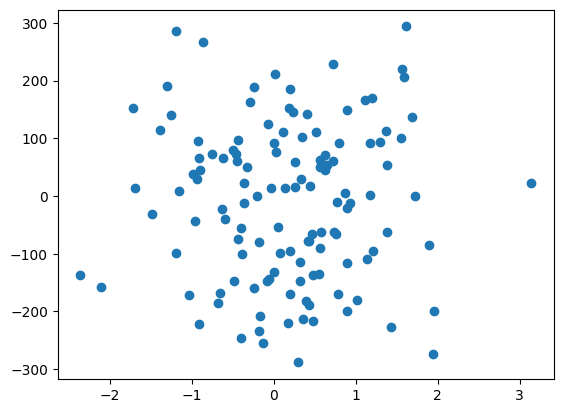

In [11]:
plt.scatter(x[1], y)

Для построения линии модели просто использовать plot вот так: plt.plot(x[1], y) будет уже неправильно. Лучше построить равномерное распределение точек от минимального до максимального по X и уже по нему расчитать модельные значения:

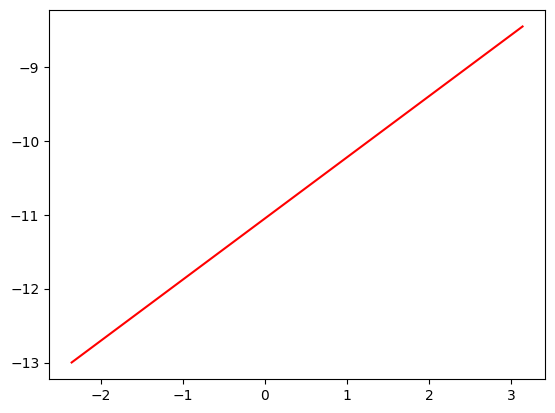

In [12]:
xx = np.linspace(x[1].min(), x[1].max(), 100).reshape((-1, 1))
plt.plot(xx, binary.predict(xx), c='r')

Для оценки качества построенной регрессии можно использовать целый ряд показателей. Одним из самых простых и универсальных является коэффициент детерминации (R2-score). Как использовать его читайте в официальной документации sklearn. Методом score можно узнать значение метрики эффективности полученной модели:

In [13]:
reg.score(X, Y)

NameError: name 'reg' is not defined